# ¿Cual es el Comportamiento de las habilidades a lo Largo del Año?

## Proposito del Notebook
- Encontrar los 3 puestos de trabajos con mayor cantidad de ofertas.
- Encontrar el top 5 habilidades más solicitadas para esos puestos de trabajo. 
- Realizar un análisis a lo largo del año, para cada trabajo con las habilidades que se requieren.
- Graficar todo en un subplot.

## Cargar librerias y el archivo

In [1]:
import pandas as pd 
from rutas import ruta_archivo_limpio
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_parquet(ruta_archivo_limpio())
df_trabajar = df.copy()
df_trabajar

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'programming': ['py..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'analyst_tools': None, 'programming': ['pytho..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'analyst_tools': None, 'programming': ['bash'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'analyst_tools': None, 'programming': ['bash'..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel'], 'pr..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'analyst_tools': None, 'programming': ['pytho..."


## Proceso de Creación del Grafico

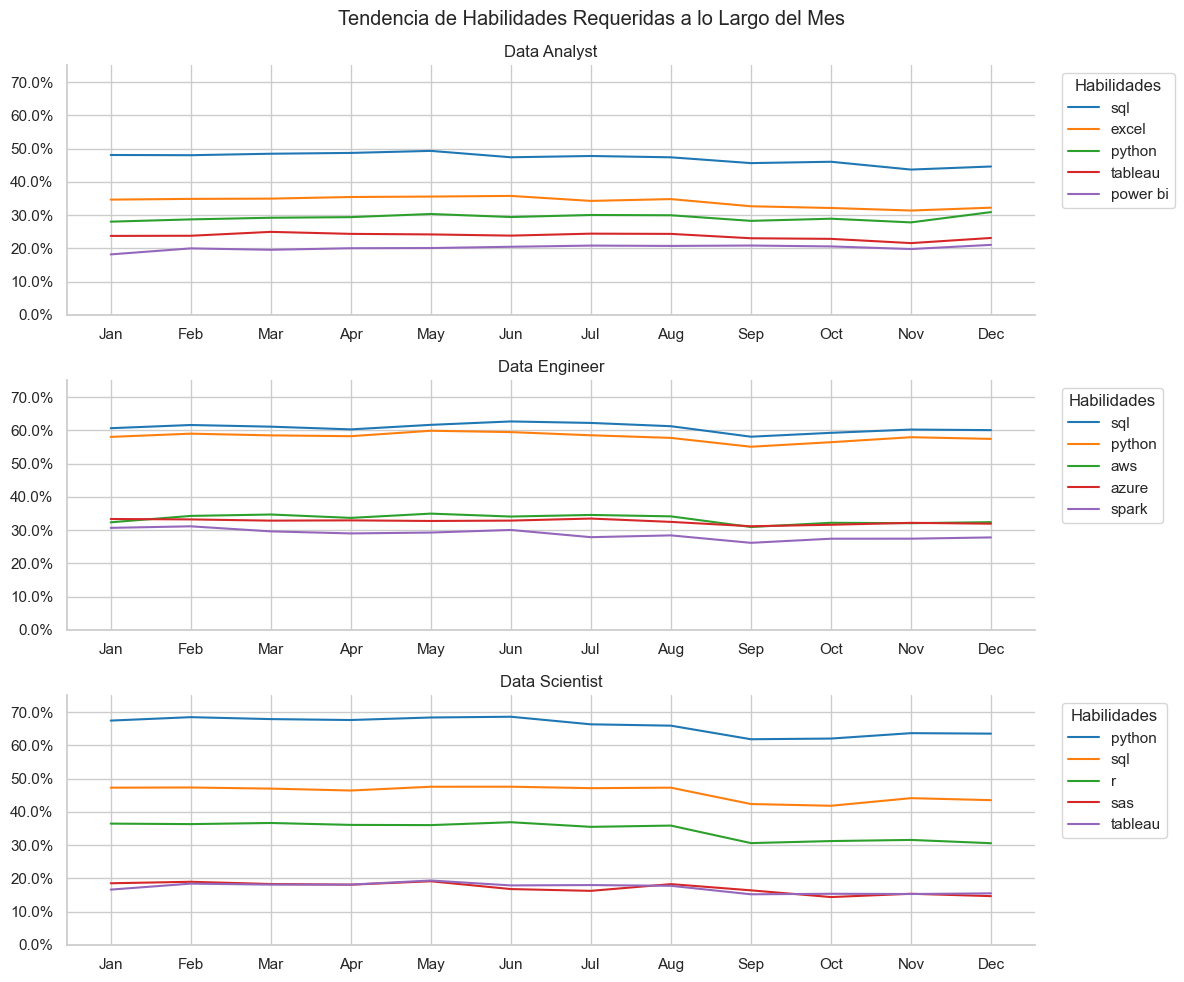

In [2]:
# Lista del nombre de los 3 roles con mayor cantidad de ofertas 
top_3_roles = df_trabajar.job_title_short.value_counts().head(3).index.to_list()

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(3,1,figsize= (12,10))
for i, rol in enumerate(top_3_roles): 
    df_grafi_tra = df_trabajar[df_trabajar.job_title_short == rol].copy()
    df_grafi_tra['mes_num'] = df_grafi_tra.job_posted_date.dt.month
    
    # cantidad de filas por número de mes 
    canti_por_mes = df_grafi_tra.mes_num.value_counts().sort_index()
    
    # Expande la lista de hábilidades 
    df_explode = df_grafi_tra.explode(column='job_skills')
    
    # top 5 habilidades por cada mes 
    df_pivot_table = df_explode.pivot_table(index='mes_num',columns='job_skills',aggfunc='size')
    df_pivot_table.loc['total'] = df_pivot_table.sum()
    df_pivot_table = df_pivot_table[df_pivot_table.loc['total'].sort_values(ascending=False).index]
    df_pivot_table = df_pivot_table.iloc[:,0:5]
    df_pivot_table.drop(index='total',inplace=True)
    
    # Divide el total de las skills por mes entre el total del mes para obtener el porcentaje
    df_porcentaje = df_pivot_table.div(canti_por_mes/100,axis=0)
    
    # Cambia el formato de numero de mes a mes corto 
    df_grafico = df_porcentaje.reset_index()
    df_grafico['mes_nombre'] = pd.to_datetime(df_grafico.mes_num,format='%m').dt.strftime('%b')
    df_grafico.set_index('mes_nombre',inplace=True)
    df_grafico.drop(columns='mes_num',inplace=True)
    
    # Grafico y Diseño 
    sns.lineplot(data=df_grafico,dashes=False,palette='tab10',ax=ax[i])
    ax[i].set_title(rol)
    ax[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'{y}%'))
    ax[i].set_xlabel('')
    ax[i].set_ylim(0,75)
    ax[i].legend(title="Habilidades", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.despine()
fig.suptitle('Tendencia de Habilidades Requeridas a lo Largo del Mes')
fig.tight_layout()